# V3 empirical study — 1.5-year monthly calibration

**This notebook is the computational source of truth.** The PDF in this folder is written from the same `payload` dict, so every table number matches.

| Item | Setting |
|------|---------|
| Models | GBM, GARCH, Heston, Merton, GARCH–Merton, Heston–Merton |
| Companies | SPY, AAPL, MSFT |
| Regimes | Crisis 2008-08-01→2009-07-31 · Normal 2014-01-01→2014-12-31 · Late-cycle 2018-10-01→2019-09-30 · COVID 2019-09-01→2020-08-31 |
| Calibration | **1.5-year** lookback, **monthly** recalibration |
| Primary metric | Percentage RMSE |
| Secondary | MAE, Bias $ (model − market), Bias%, Early-exercise fraction |
| Paths | LSM American calls, `n_paths=10000`, `seed=42` |
| Code | V3 notebooks + `option_filters.py` + Euler-corrected Heston step |

In every table the **BEST** model is the lowest RMSE%. That row is **bold and green**.


## 0. Methodology and conditions

### No look-ahead
At monthly update t, parameters use only returns and listed quotes with `trading_date ≤ t`. LSM prices a Monday contract with the latest calibration row dated on or before that Monday. Option quotes are as-of the grid timestamp (same session, else the prior session).

### Shared sample (no model-specific data selection)
For each company × regime the Monday nearest-ATM listed-call sample is drawn **once** and passed to all six models. Filters, testing dates, simulation settings, and the market benchmark are therefore identical.

### Filters (applied in this order)
1. Calls only; finite S, K, C.
2. No-arbitrage: C ≥ max(0, S−K).
3. Maturity: 7 ≤ DTE ≤ 60.
4. Moneyness: |S/K − 1| ≤ 10%.
5. Liquidity: premium ≥ 0.05; valid bid–ask and relative spread ≤ 50% when those columns exist; volume ≥ 1 when present.

### Metrics
- Primary: RMSE%.
- Secondary: MAE (dollars), Bias $ = mean(model − market), **Bias% = 100 × mean((model − market)/market)**, early-exercise fraction.
- Ranking uses RMSE% only. The dollar bias column is kept; Bias% is the scale-free companion.

### Model-correctness adjustments
- Heston / Heston–Merton: option-implied Fourier NLS for (κ, θ, ξ, ρ, v0). Not Method A.
- Euler: stock return over [t, t+Δt] uses **current** v_t; then update v_{t+Δt}.
- LSM never averages paths before stopping.

### Data limits
Equity adj-close starts **2003-12-01**. Listed-option panels start **2008-01**. Estimators use all available history when the requested lookback is longer than the file.

### Re-run
Set `RECOMPUTE = True` in the next cell and Run All. Default loads `payload.json` if the 12×6 cells are already complete, then rewrites the PDF from that payload.


In [1]:
import sys
from pathlib import Path
from IPython.display import display, HTML, Markdown, Image
ROOT = Path.cwd()
for cand in [ROOT, *ROOT.parents]:
    scripts = cand / 'V3-Models_result' / 'scripts'
    if scripts.exists():
        sys.path.insert(0, str(scripts))
        break
import run_v3_1p5y_10k_monthly_empirical_study as study
RECOMPUTE = False  # True to re-run all 72 calibrations + LSM
payload = study.run_or_load(recompute=RECOMPUTE)
print('cells', len(payload['cells']), 'failures', payload['meta']['failures'])
pdf_path = study.write_pdf(payload)
print('PDF', pdf_path)

## 1. Shared evaluation sample


In [1]:
from IPython.display import HTML, display
rows = ['<h4>n contracts (identical across models)</h4>']
display(HTML(''.join(study._html_table(payload['tables'][k]) if False else '')))
meta = payload['shared_contracts']
import pandas as pd
df = pd.DataFrame([{ 'regime': r, **meta[r]['n'], 'start': meta[r]['period_start'], 'end': meta[r]['period_end']} for r in study.REGIME_ORDER])
display(df)

Regime,Window,SPY,AAPL,MSFT
2008-2009 Crisis,2008-08-01 → 2009-07-31,50,50,50
2013-2014 Normal,2014-01-01 → 2014-12-31,50,50,50
2018-2019 Late-cycle,2018-10-01 → 2019-09-30,50,51,50
2019-2020 COVID,2019-09-01 → 2020-08-31,50,50,50


## 2.1 Detailed tables — `SPY`


### Table SPY-1. SPY · 2008-2009 · Crisis

2008-08-01 → 2009-07-31 · n = 50 contracts · **BEST = Heston–Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['SPY|2008-2009'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,55.01,1.4054,+0.2705,+21.16,24.5%,6
GARCH,52.86,1.6883,+1.6456,+43.57,20.8%,3
Heston,32.75,1.0960,+0.5803,+20.80,26.9%,2
Merton,52.87,1.3685,+0.1826,+18.56,20.3%,4
GARCH–Merton,54.76,1.7780,+1.7384,+46.28,20.5%,5
Heston–Merton,31.60,1.0435,+0.5375,+19.11,21.4%,1


### Table SPY-2. SPY · 2013-2014 · Normal

2014-01-01 → 2014-12-31 · n = 50 contracts · **BEST = Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['SPY|2013-2014'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,38.08,0.6850,+0.4678,+24.88,26.1%,2
GARCH,38.24,0.6860,+0.4700,+24.96,23.3%,3
Heston,52.46,1.0201,+0.9451,+42.44,26.9%,5
Merton,37.52,0.6728,+0.4520,+24.20,24.7%,1
GARCH–Merton,42.83,0.7744,+0.6153,+30.82,22.5%,4
Heston–Merton,67.16,1.2748,+1.2103,+53.41,24.5%,6


### Table SPY-3. SPY · 2018-2019 · Late-cycle

2018-10-01 → 2019-09-30 · n = 50 contracts · **BEST = Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['SPY|2018-2019'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,49.51,1.6628,+1.1528,+32.90,21.8%,2
GARCH,71.72,2.1416,+1.7421,+45.61,21.9%,3
Heston,73.93,2.3623,+2.1183,+54.85,22.3%,4
Merton,47.62,1.5845,+1.0524,+30.44,16.2%,1
GARCH–Merton,77.02,2.4122,+2.1360,+54.80,20.5%,5
Heston–Merton,84.01,2.7641,+2.5349,+64.41,17.0%,6


### Table SPY-4. SPY · 2019-2020 · COVID

2019-09-01 → 2020-08-31 · n = 50 contracts · **BEST = GARCH** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['SPY|2019-2020'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,64.88,3.6003,+1.6141,+44.13,23.9%,3
GARCH,56.59,2.9250,+2.0268,+34.97,32.7%,1
Heston,65.44,3.7704,+2.6179,+50.30,26.4%,4
Merton,60.38,3.3441,+1.2734,+38.99,18.7%,2
GARCH–Merton,66.14,3.4255,+2.8053,+46.06,31.4%,5
Heston–Merton,66.64,3.5171,+2.3874,+47.68,15.7%,6


## 2.2 Detailed tables — `AAPL`


### Table AAPL-1. AAPL · 2008-2009 · Crisis

2008-08-01 → 2009-07-31 · n = 50 contracts · **BEST = Heston** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AAPL|2008-2009'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,57.67,2.4326,+1.3849,+31.10,22.8%,5
GARCH,48.71,2.7044,+2.5500,+40.72,19.1%,3
Heston,31.71,1.5996,+1.0721,+21.09,22.7%,1
Merton,55.67,2.3640,+1.2255,+28.42,18.3%,4
GARCH–Merton,58.94,3.2224,+3.1062,+50.39,15.9%,6
Heston–Merton,32.30,1.6138,+1.0704,+21.37,18.5%,2


### Table AAPL-2. AAPL · 2013-2014 · Normal

2014-01-01 → 2014-12-31 · n = 50 contracts · **BEST = Heston–Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AAPL|2013-2014'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,50.20,3.5766,+3.5387,+38.63,24.6%,5
GARCH,45.44,3.1849,+3.0454,+29.67,22.2%,3
Heston,37.85,2.5745,+2.5702,+29.62,20.8%,2
Merton,45.50,3.2302,+3.1799,+33.94,19.5%,4
GARCH–Merton,65.87,4.9053,+4.9027,+53.60,17.8%,6
Heston–Merton,31.91,1.9670,+1.9420,+21.53,15.2%,1


### Table AAPL-3. AAPL · 2018-2019 · Late-cycle

2018-10-01 → 2019-09-30 · n = 51 contracts · **BEST = Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AAPL|2018-2019'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,32.53,1.7033,+1.0081,+18.76,23.9%,2
GARCH,48.45,2.0164,+1.5757,+29.40,20.0%,5
Heston,45.14,2.3820,+2.2976,+38.59,21.0%,4
Merton,30.59,1.5914,+0.8543,+16.31,19.9%,1
GARCH–Merton,59.31,2.6521,+2.3998,+42.76,18.5%,6
Heston–Merton,41.69,2.0875,+1.9310,+32.87,18.2%,3


### Table AAPL-4. AAPL · 2019-2020 · COVID

2019-09-01 → 2020-08-31 · n = 50 contracts · **BEST = Heston–Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AAPL|2019-2020'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,46.19,3.9995,+2.3663,+30.76,23.8%,4
GARCH,61.17,4.8546,+4.4651,+43.67,24.2%,5
Heston,42.24,3.7296,+2.9444,+33.15,23.3%,2
Merton,43.61,3.6886,+1.9753,+27.36,18.9%,3
GARCH–Merton,71.81,5.9515,+5.7532,+57.54,24.2%,6
Heston–Merton,40.88,3.4396,+2.5150,+30.03,16.7%,1


## 2.3 Detailed tables — `MSFT`


### Table MSFT-1. MSFT · 2008-2009 · Crisis

2008-08-01 → 2009-07-31 · n = 50 contracts · **BEST = Heston** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['MSFT|2008-2009'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,44.02,0.3723,+0.0897,+17.99,24.1%,4
GARCH,70.79,0.5879,+0.5440,+54.27,30.0%,5
Heston,26.51,0.2560,+0.0897,+12.61,24.7%,1
Merton,42.94,0.3684,+0.0716,+16.18,19.7%,3
GARCH–Merton,81.24,0.6935,+0.6704,+66.90,29.6%,6
Heston–Merton,26.84,0.2552,+0.0910,+12.75,18.6%,2


### Table MSFT-2. MSFT · 2013-2014 · Normal

2014-01-01 → 2014-12-31 · n = 50 contracts · **BEST = Heston–Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['MSFT|2013-2014'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,62.49,0.4283,+0.4261,+52.98,24.7%,4
GARCH,90.24,0.6511,+0.6511,+78.36,25.2%,5
Heston,31.79,0.1889,+0.1565,+21.39,22.6%,2
Merton,54.85,0.3679,+0.3602,+45.39,17.1%,3
GARCH–Merton,112.93,0.8656,+0.8656,+102.63,21.6%,6
Heston–Merton,26.54,0.1648,+0.1181,+16.70,12.2%,1


### Table MSFT-3. MSFT · 2018-2019 · Late-cycle

2018-10-01 → 2019-09-30 · n = 50 contracts · **BEST = Heston–Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['MSFT|2018-2019'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,41.73,1.0839,+0.8054,+27.55,23.0%,4
GARCH,42.43,1.0703,+0.9006,+30.13,18.9%,5
Heston,37.47,0.9577,+0.8192,+26.22,21.8%,2
Merton,40.33,1.0504,+0.7474,+25.77,19.8%,3
GARCH–Merton,52.89,1.3664,+1.2944,+42.08,17.0%,6
Heston–Merton,33.23,0.7984,+0.6200,+19.90,16.2%,1


### Table MSFT-4. MSFT · 2019-2020 · COVID

2019-09-01 → 2020-08-31 · n = 50 contracts · **BEST = Heston–Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['MSFT|2019-2020'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,45.93,2.0118,+1.0018,+28.12,24.5%,4
GARCH,60.29,2.3979,+1.9268,+35.85,29.6%,5
Heston,40.67,2.0782,+1.5079,+30.43,23.8%,2
Merton,44.13,1.8737,+0.7910,+25.02,19.7%,3
GARCH–Merton,346.80,6.7038,+6.3160,+88.26,28.7%,6
Heston–Merton,35.19,1.7711,+1.0681,+20.23,16.0%,1


## 3. Summary tables


### Table S1 — Overall ranking


In [1]:
display(HTML('overall ranking table is rendered from payload["summary_overall"]'))

Rank,Model,Mean RMSE%,Median RMSE%,# cells best
1,Heston BEST,43.16,39.26,2
2,Heston–Merton,43.16,34.21,6
3,Merton,46.33,44.82,3
4,GBM,49.02,47.85,0
5,GARCH,57.25,54.73,1
6,GARCH–Merton,90.88,66.00,0


## 4. Figures


### Figure 1 — RMSE% by regime (mean of three companies)


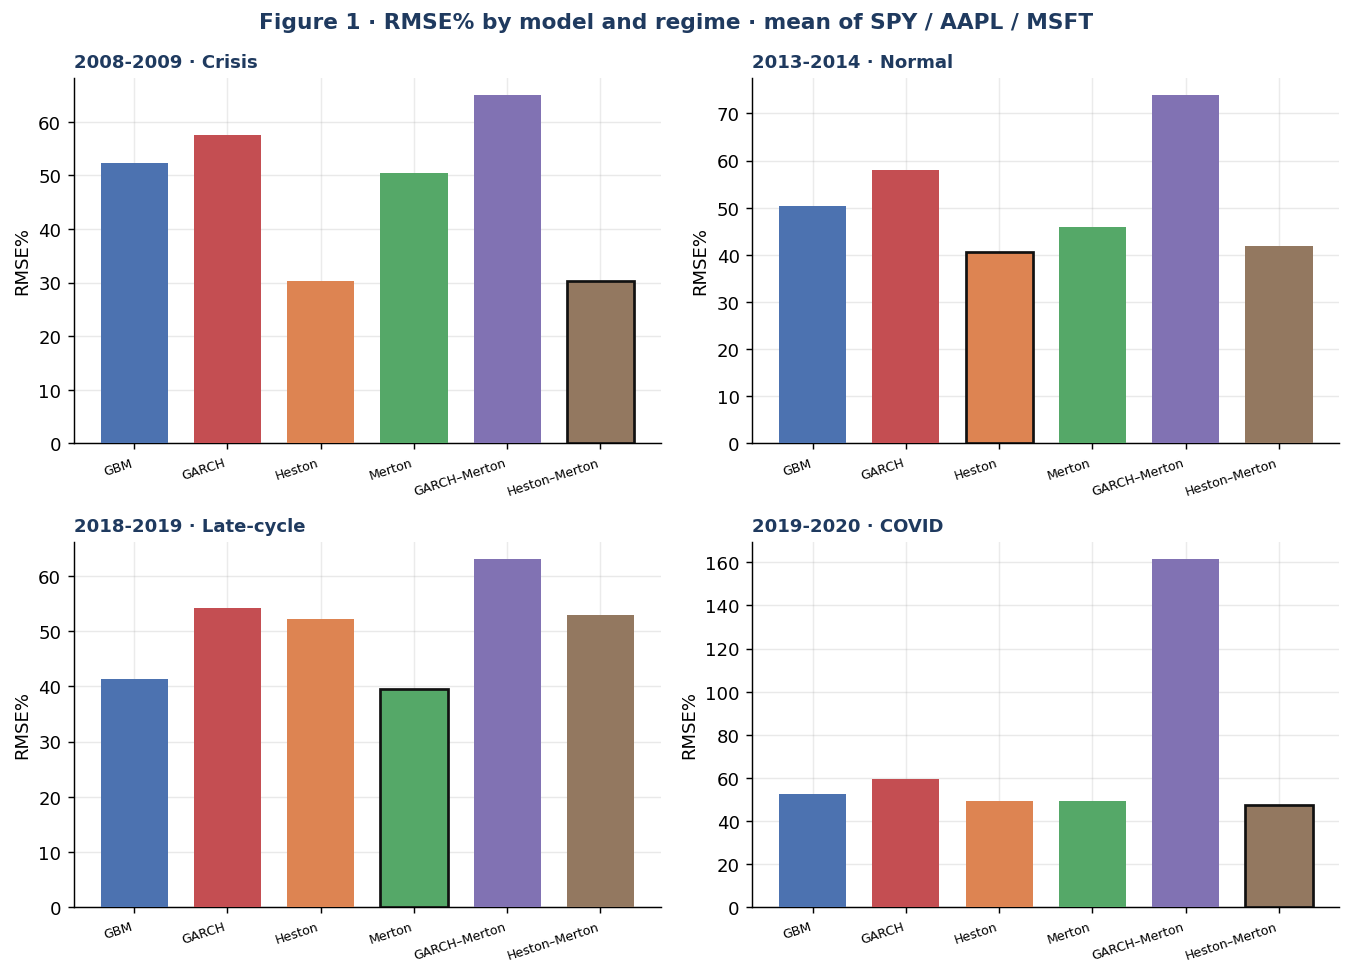

In [1]:
pass  # figure embedded from the same payload used for the PDF

### Figure 2 — RMSE% by company


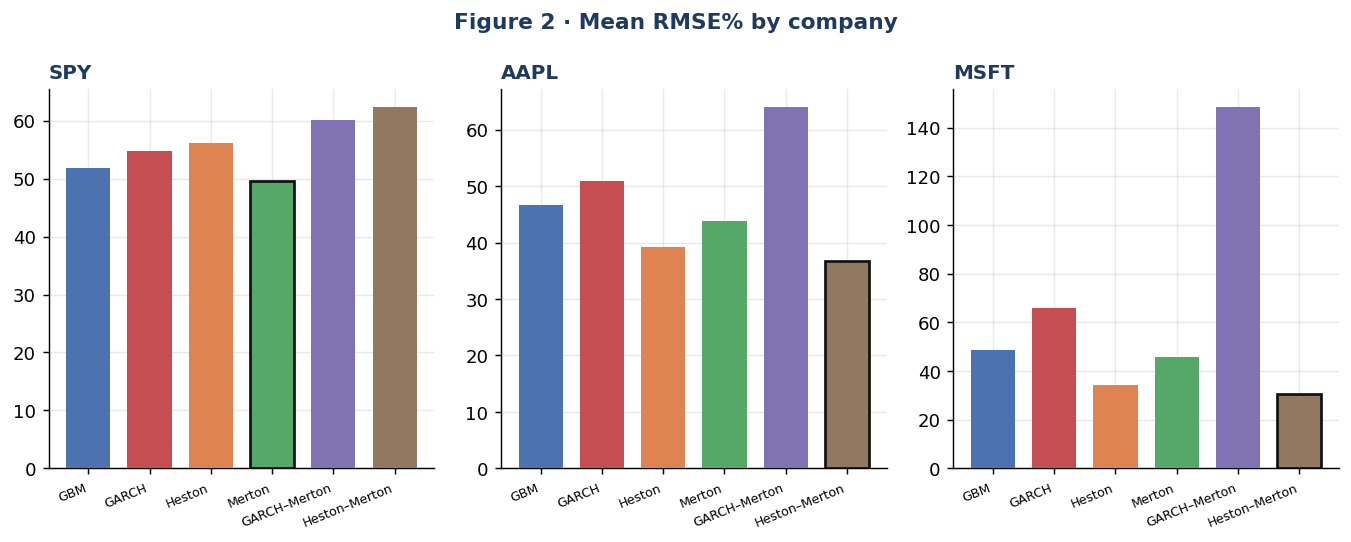

In [1]:
pass

### Figure 3 — Rank heatmap


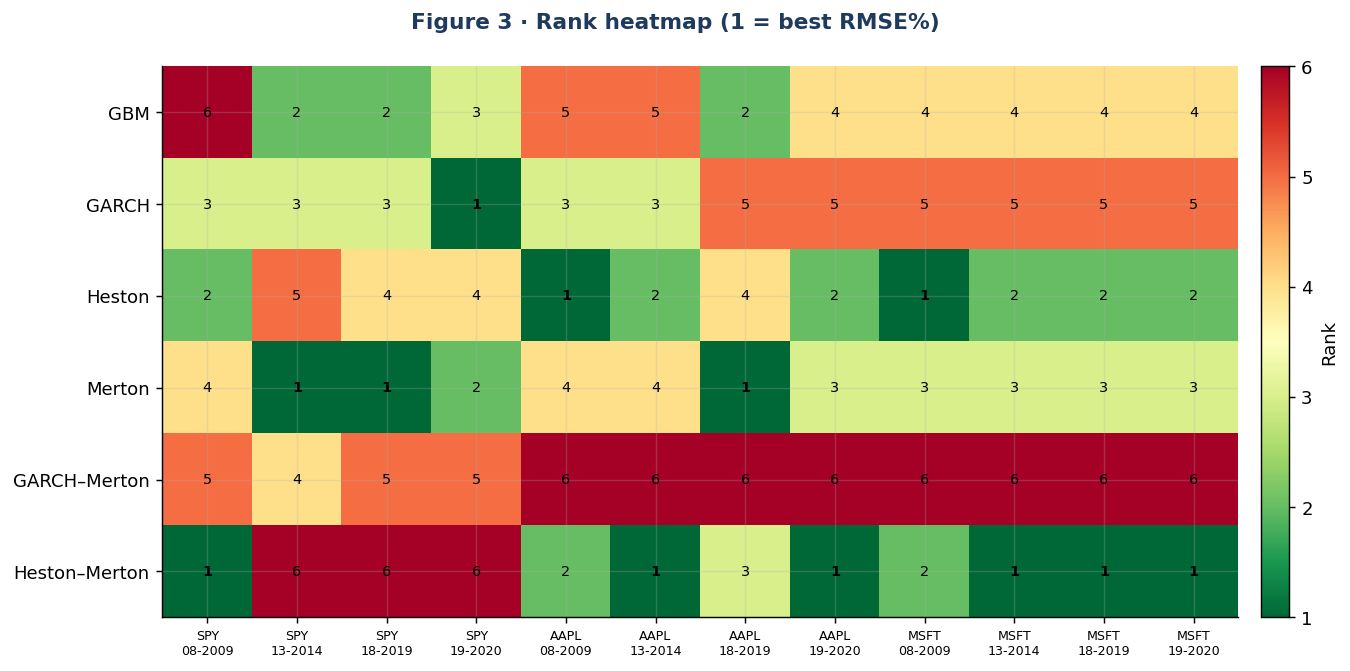

In [1]:
pass

## 5. Final analysis

- On mean percentage RMSE across the 12 company×regime cells, Heston is the best overall model (mean RMSE% = 43.16; 2 of 12 cells).

- Second overall is Heston–Merton (mean RMSE% = 43.16; 6 cells).

- The ranking is not stable. Best-in-cell models across the 12 tables: GARCH, Heston, Heston–Merton, Merton.

- SPY: lowest mean RMSE% is Merton (49.60); wins 2 of 4 regimes.

- AAPL: lowest mean RMSE% is Heston–Merton (36.69); wins 2 of 4 regimes.

- MSFT: lowest mean RMSE% is Heston–Merton (30.45); wins 3 of 4 regimes.

- 2008-2009 (Crisis): best mean RMSE% is Heston–Merton (30.24).

- 2013-2014 (Normal): best mean RMSE% is Heston (40.70).

- 2018-2019 (Late-cycle): best mean RMSE% is Merton (39.51).

- 2019-2020 (COVID): best mean RMSE% is Heston–Merton (47.57).

- No-jump models as a group have lower mean RMSE% (49.81) than the three jump models (60.13).

- For the overall winner (Heston), crisis RMSE% is 30.32 vs 40.70 in the 2014 normal year — absolute pricing error is regime-dependent even when the ranking is not.

- These conclusions are conditional on the V3 filters, 1.5-year monthly calibration, Monday ATM sample, LSM with 10,000 paths, and American-call quotes only. They are not a statement about European options or other tenors.


## 6. Reproducibility

```python
RECOMPUTE = True
payload = study.run_or_load(recompute=True)
study.write_pdf(payload)
study.build_notebook(payload)
```

Partial results resume from `V3-Models_result/results/empirical_study_1p5y_monthly_10000/partial/`.
Shared contracts are frozen in `shared_contracts.json` so a resumed run cannot silently change the sample.
